In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

In [2]:
# 1) Load
df = pd.read_csv("Mall_Customers.csv")  # <- change path if needed

In [3]:
# 2) Quick checks
print(df.shape)
display(df.head())
display(df.describe(include="all"))

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


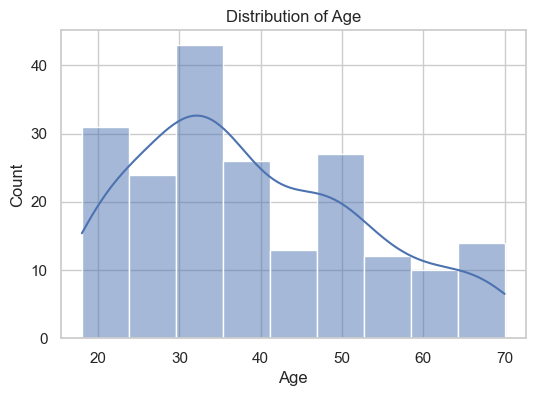

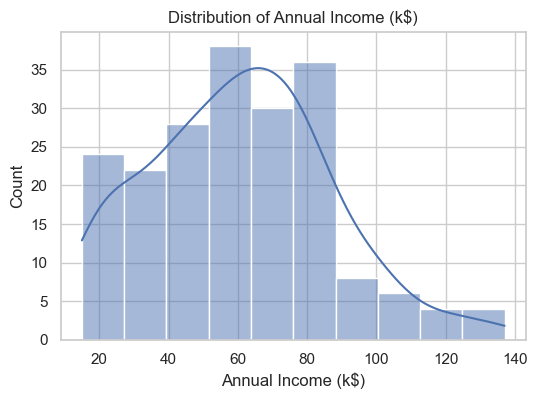

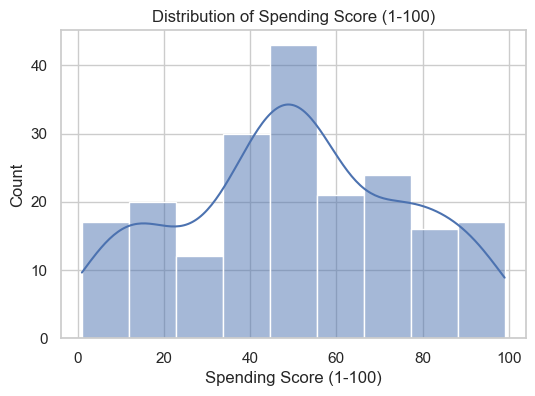

In [4]:
# 3) Basic distribution plots
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


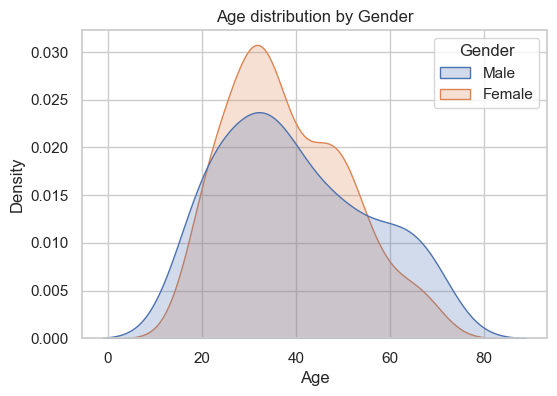

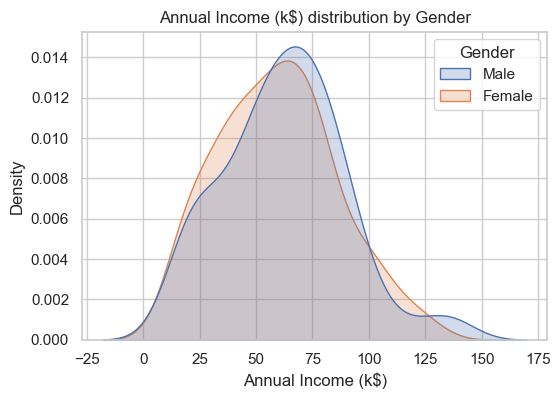

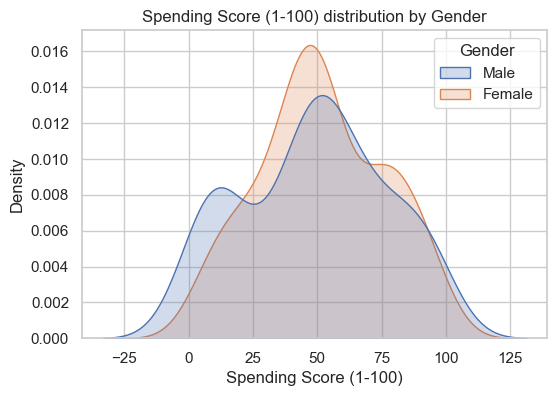

In [5]:
# 4) Distributions by Gender (fixed)
for col in cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="Gender", fill=True, common_norm=False)
    plt.title(f"{col} distribution by Gender")
    plt.show()

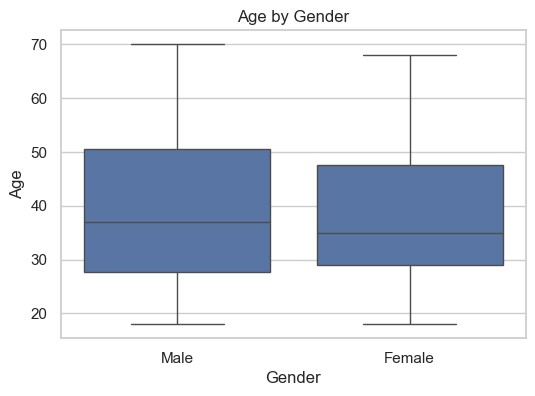

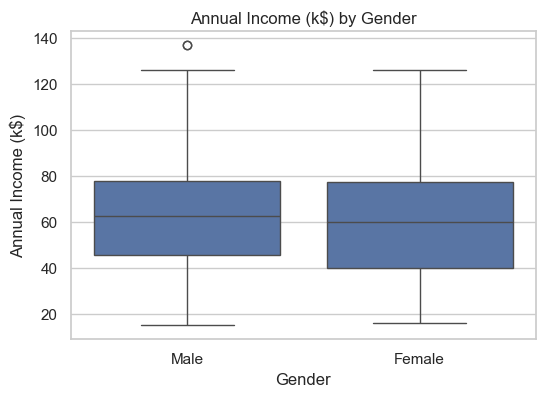

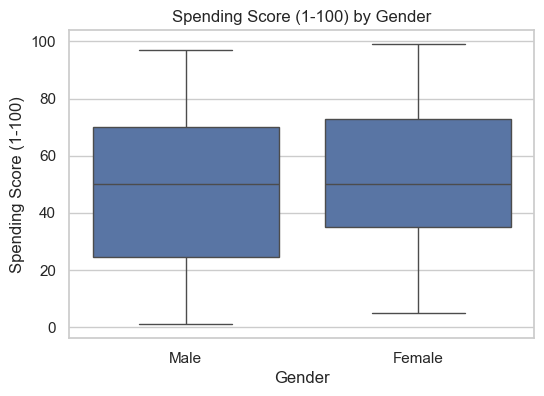

In [6]:
# 5) Boxplots by Gender
for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Gender", y=col)
    plt.title(f"{col} by Gender")
    plt.show()

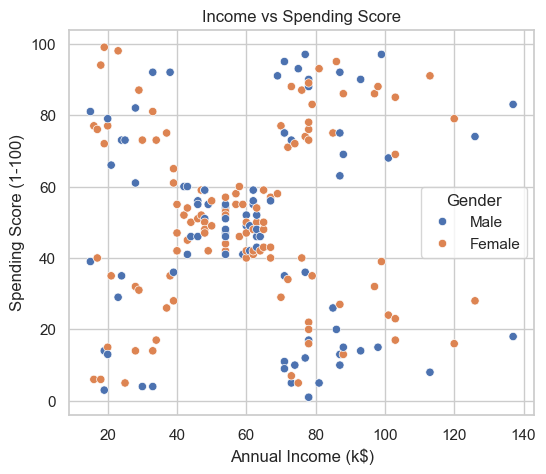

In [7]:
# 6) Relationship: Income vs Spending
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue="Gender")
plt.title("Income vs Spending Score")
plt.show()

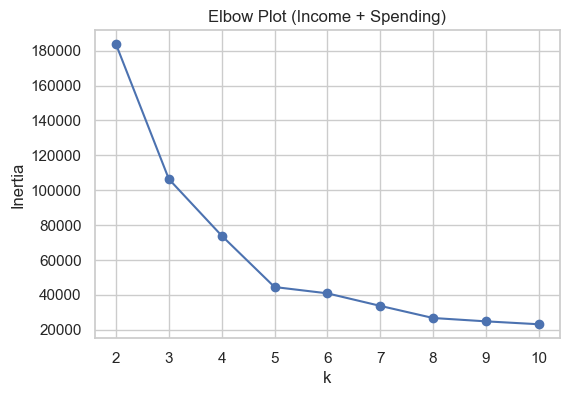

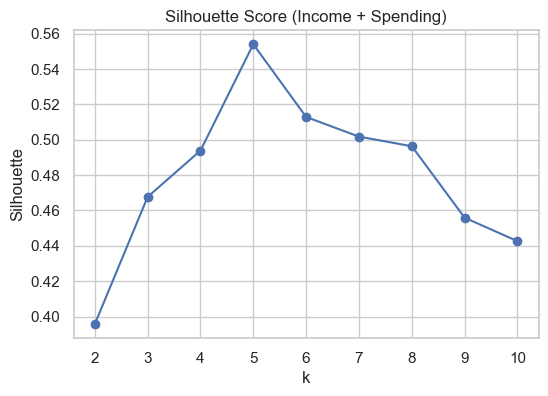

Best k by silhouette: 5


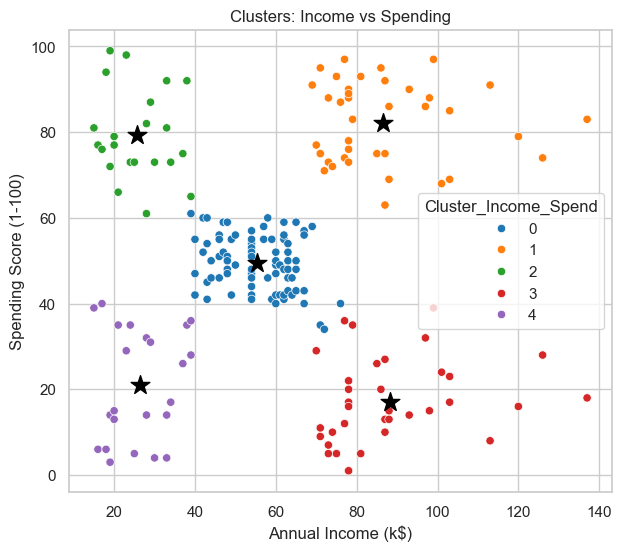

In [8]:
# 7) Cluster selection (Bivariate): Income + Spending
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']]

inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X2)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X2, labels))

plt.figure(figsize=(6,4))
plt.plot(k_range, inertias, marker="o")
plt.title("Elbow Plot (Income + Spending)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_range, sil_scores, marker="o")
plt.title("Silhouette Score (Income + Spending)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

# Pick k (often 5 for this dataset, but let silhouette guide you)
k_best = k_range[np.argmax(sil_scores)]
print("Best k by silhouette:", k_best)

km2 = KMeans(n_clusters=k_best, random_state=42, n_init="auto")
df["Cluster_Income_Spend"] = km2.fit_predict(X2)

centers = pd.DataFrame(km2.cluster_centers_, columns=X2.columns)

plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue="Cluster_Income_Spend", palette="tab10")
plt.scatter(centers['Annual Income (k$)'], centers['Spending Score (1-100)'], s=200, marker="*", c="black")
plt.title("Clusters: Income vs Spending")
plt.show()

In [9]:
# 8) Cluster profiling table (THIS is where insights come from)
profile = df.groupby("Cluster_Income_Spend").agg(
    count=("CustomerID","count") if "CustomerID" in df.columns else ("Age","count"),
    avg_age=("Age","mean"),
    avg_income=('Annual Income (k$)',"mean"),
    avg_spend=('Spending Score (1-100)',"mean")
).round(2).sort_values("avg_income")

display(profile)

# Gender mix inside each cluster
gender_mix = pd.crosstab(df["Cluster_Income_Spend"], df["Gender"], normalize="index").round(3)
display(gender_mix)

,count,avg_age,avg_income,avg_spend
Cluster_Income_Spend,,,,
2,22,25.27,25.73,79.36
4,23,45.22,26.30,20.91
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
3,35,41.11,88.20,17.11


Gender,Female,Male
Cluster_Income_Spend,,
0,0.593,0.407
1,0.538,0.462
2,0.591,0.409
3,0.457,0.543
4,0.609,0.391


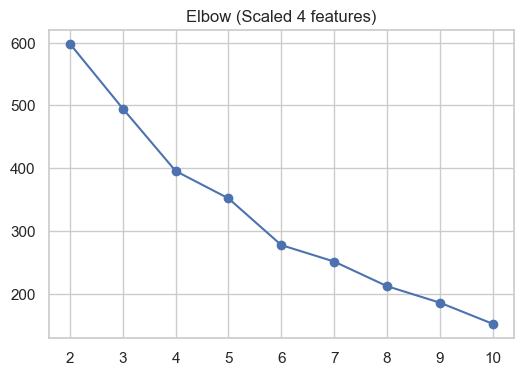

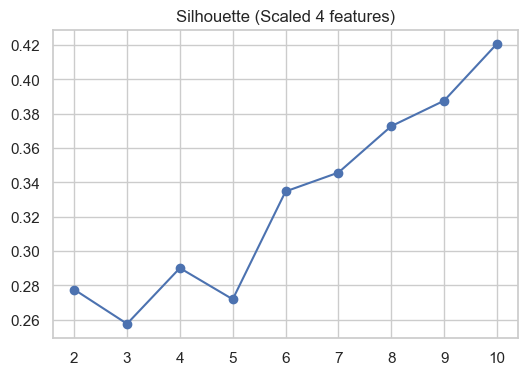

Best k (4 features) by silhouette: 10


,count,avg_age,avg_income,avg_spend
Cluster_All,,,,
8,13,25.46,25.69,80.54
2,14,41.21,26.07,20.14
1,24,25.25,41.25,60.92
0,26,58.85,48.69,39.85
4,26,54.15,54.23,48.96
6,25,27.96,57.36,47.12
5,19,38.47,85.89,14.21
3,21,32.19,86.05,81.67
7,18,33.28,87.11,82.67


In [10]:
# 9) Multivariate clustering (Age + Income + Spending + Gender)
df2 = df.copy()
df2["Gender_Male"] = (df2["Gender"] == "Male").astype(int)

X4 = df2[['Age','Annual Income (k$)','Spending Score (1-100)','Gender_Male']]

scaler = StandardScaler()
X4_scaled = scaler.fit_transform(X4)

inertias4 = []
sil4 = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X4_scaled)
    inertias4.append(km.inertia_)
    sil4.append(silhouette_score(X4_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(k_range, inertias4, marker="o")
plt.title("Elbow (Scaled 4 features)")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_range, sil4, marker="o")
plt.title("Silhouette (Scaled 4 features)")
plt.show()

k4_best = k_range[np.argmax(sil4)]
print("Best k (4 features) by silhouette:", k4_best)

km4 = KMeans(n_clusters=k4_best, random_state=42, n_init="auto")
df["Cluster_All"] = km4.fit_predict(X4_scaled)

profile_all = df.groupby("Cluster_All").agg(
    count=("Age","count"),
    avg_age=("Age","mean"),
    avg_income=('Annual Income (k$)',"mean"),
    avg_spend=('Spending Score (1-100)',"mean")
).round(2).sort_values("avg_income")

display(profile_all)